<a href="https://colab.research.google.com/github/JesmirData/Butterfly2.0/blob/main/Proyecto_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objetivo: Utilizando el Modelo de Regresion Lineal se propone como una pregunta que se puede defender con datos: ¿cuánto se desvía en 2024 y 2025 una recta entrenada con la producción mensual de YPF en Neuquén en el periodo 2009 hasta 2023? Compararemos la recta con una referencia sencilla. Si falla, explicaremos cuánto falla y desde cuándo

In [1]:
from google.colab import drive, files
from pathlib import Path
import pandas as pd
import shutil

if not Path("/content/drive/MyDrive").is_dir():
    drive.mount("/content/drive")

carpeta = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

archivos = {
    "Histórico": carpeta / "YPF.csv",
    "2023": carpeta / "produccin-de-pozos-de-gas-y-petrleo-2023.csv",
    "2024": carpeta / "produccin-de-pozo.csv",
    "2025": carpeta / "produccin-de-pozos-de-gas-y-petrle.csv",
}

ruta_historico = archivos["Histórico"]

if not ruta_historico.exists():
    candidatos = sorted(
        Path("/content").glob("YPF*.csv"),
        key=lambda ruta: ruta.stat().st_mtime,
        reverse=True,
    )

    if candidatos:
        origen = candidatos[0]
    else:
        print("Selecciona tu CSV histórico de YPF.")
        subidos = files.upload()
        if len(subidos) != 1:
            raise ValueError("Selecciona un solo archivo CSV.")
        origen = Path.cwd() / next(iter(subidos))

    columnas = set(pd.read_csv(origen, nrows=0).columns)
    necesarias = {"Company", "Year", "Month", "Province", "Amount", "Concept"}

    if not necesarias.issubset(columnas):
        raise ValueError(f"El archivo {origen.name} no tiene las columnas esperadas.")

    shutil.copyfile(origen, ruta_historico)
    print(f"Copiado a Drive: {origen.name} → YPF.csv")

for periodo, ruta in archivos.items():
    if not ruta.is_file():
        raise FileNotFoundError(f"Falta el archivo de {periodo}: {ruta}")
    print(f"{periodo}: OK — {ruta.name}")

historico = pd.read_csv(ruta_historico)

print("\nFilas del histórico:", len(historico))
print("Años:", historico["Year"].min(), "a", historico["Year"].max())
print("Columnas:", historico.columns.tolist())
display(historico.head(3))

Mounted at /content/drive
Histórico: OK — YPF.csv
2023: OK — produccin-de-pozos-de-gas-y-petrleo-2023.csv
2024: OK — produccin-de-pozo.csv
2025: OK — produccin-de-pozos-de-gas-y-petrle.csv

Filas del histórico: 237600
Años: 2009 a 2023
Columnas: ['Company', 'Year', 'Month', 'Province', 'Amount', 'Time_Index', 'Deposit_Area', 'Concept', 'Basin']


,Company,Year,Month,Province,Amount,Time_Index,Deposit_Area,Concept,Basin
0,YPF S.A.,2009,1,Neuquen,0.00,2009-01,LOMA LA LATA ESTE,Produccion Primaria (m3),NEUQUINA
1,YPF S.A.,2009,1,Neuquen,0.00,2009-01,PUESTO HERNANDEZ,Produccion Primaria (m3),NEUQUINA
2,YPF S.A.,2009,1,Neuquen,2099.07,2009-01,SIERRA BARROSA,Produccion de Agua (m3),NEUQUINA


In [2]:
fechas = pd.to_datetime(
    dict(year=historico["Year"], month=historico["Month"], day=1)
)

print("Histórico desde:", fechas.min().strftime("%Y-%m"))
print("Histórico hasta:", fechas.max().strftime("%Y-%m"))
display(historico.tail(5))

Histórico desde: 2009-01
Histórico hasta: 2023-06


,Company,Year,Month,Province,Amount,Time_Index,Deposit_Area,Concept,Basin
237595,YPF S.A.,2023,6,Neuquen,0.0,2023-06,EL TOMILLO,Produccion No Convencional (m3),NEUQUINA
237596,YPF S.A.,2023,6,Neuquen,0.0,2023-06,BAJO DEL TORO NORTE,Densidad Media (Ton/m3),NEUQUINA
237597,YPF S.A.,2023,6,Neuquen,0.0,2023-06,BANDURRIA SUR,Densidad Media (Ton/m3),NEUQUINA
237598,YPF S.A.,2023,6,Neuquen,0.0,2023-06,BAJO DEL TORO,Densidad Media (Ton/m3),NEUQUINA
237599,YPF S.A.,2023,6,Neuquen,0.0,2023-06,CERRITO DE LA COSTA,Produccion No Convencional (m3),NEUQUINA


Calculamos Produccion Mensual en Metros Cubicos M3

In [3]:
conceptos_petroleo = [
    "Produccion Primaria (m3)",
    "Produccion Secundaria (m3)",
    "Produccion por Recuperacion Asistida (m3)",
    "Produccion de Condensado (m3)",
    "Produccion de Gasolina Estabilizada (m3)",
]

serie_historica = (
    historico.loc[
        (historico["Company"] == "YPF S.A.")
        & (historico["Province"] == "Neuquen")
        & (historico["Concept"].isin(conceptos_petroleo))
    ]
    .groupby(["Year", "Month"], as_index=False)["Amount"]
    .sum()
    .rename(columns={"Amount": "produccion_m3"})
)

serie_historica["fecha"] = pd.to_datetime(
    dict(
        year=serie_historica["Year"],
        month=serie_historica["Month"],
        day=1,
    )
)
serie_historica = serie_historica[
    ["fecha", "produccion_m3"]
].sort_values("fecha").reset_index(drop=True)

print("Meses históricos:", len(serie_historica))
print("Primero:", serie_historica["fecha"].min().date())
print("Último:", serie_historica["fecha"].max().date())
display(serie_historica.tail(6))

Meses históricos: 174
Primero: 2009-01-01
Último: 2023-06-01


,fecha,produccion_m3
168,2023-01-01,907711.32
169,2023-02-01,830695.55
170,2023-03-01,948385.42
171,2023-04-01,924597.98
172,2023-05-01,956853.81
173,2023-06-01,918282.34


#Completamos Periodo 2023


In [4]:
from pathlib import Path
import pandas as pd

carpeta = Path(
    "/content/drive/MyDrive/"
    "C26240 | Machine_Learning | Talento_Techt/"
    "Proyecto YPF_ML/Datos/Datos_Utilizados"
)

conceptos = [
    "Produccion Primaria (m3)",
    "Produccion Secundaria (m3)",
    "Produccion por Recuperacion Asistida (m3)",
    "Produccion de Condensado (m3)",
    "Produccion de Gasolina Estabilizada (m3)",
]

h = (
    historico.loc[
        (historico["Company"] == "YPF S.A.")
        & (historico["Province"] == "Neuquen")
        & (historico["Concept"].isin(conceptos))
    ]
    .groupby(["Year", "Month"], as_index=False)["Amount"]
    .sum()
    .rename(columns={"Amount": "produccion_m3"})
)
h["fuente"] = "Histórico"

pozos = pd.read_csv(
    carpeta / "produccin-de-pozos-de-gas-y-petrleo-2023.csv",
    usecols=["anio", "mes", "idempresa", "provincia", "prod_pet"],
)
p = (
    pozos.loc[
        (pozos["idempresa"] == "YPF")
        & (pozos["provincia"] == "Neuquén")
        & (pozos["mes"] >= 7)
    ]
    .groupby(["anio", "mes"], as_index=False)["prod_pet"]
    .sum()
    .rename(columns={
        "anio": "Year",
        "mes": "Month",
        "prod_pet": "produccion_m3",
    })
)
p["fuente"] = "Pozos 2023"

serie = pd.concat([h, p], ignore_index=True)
serie["fecha"] = pd.to_datetime(
    dict(year=serie["Year"], month=serie["Month"], day=1)
)
serie = serie[
    ["fecha", "produccion_m3", "fuente"]
].sort_values("fecha").reset_index(drop=True)

if (
    len(serie) != 180
    or serie["fecha"].duplicated().any()
    or serie["fecha"].min() != pd.Timestamp("2009-01-01")
    or serie["fecha"].max() != pd.Timestamp("2023-12-01")
):
    raise ValueError("La serie no contiene los 180 meses esperados.")

print("Meses de entrenamiento:", len(serie))
print("Desde:", serie["fecha"].min().date())
print("Hasta:", serie["fecha"].max().date())
print("\nAño 2023: observa el cambio de fuente en julio")
display(serie.loc[serie["fecha"].dt.year == 2023])

Meses de entrenamiento: 180
Desde: 2009-01-01
Hasta: 2023-12-01

Año 2023: observa el cambio de fuente en julio


,fecha,produccion_m3,fuente
168,2023-01-01,907711.32,Histórico
169,2023-02-01,830695.55,Histórico
170,2023-03-01,948385.42,Histórico
171,2023-04-01,924597.98,Histórico
172,2023-05-01,956853.81,Histórico
173,2023-06-01,918282.34,Histórico
174,2023-07-01,936667.41,Pozos 2023
175,2023-08-01,940422.76,Pozos 2023
176,2023-09-01,949228.98,Pozos 2023
177,2023-10-01,1066015.44,Pozos 2023


Realizamos un Analisis Exploratorio de los Datos


Meses sin registro: 0
Fechas duplicadas: 0
Producción faltante: 0
Producción negativa: 0

Distribución de la producción mensual (m³):


,produccion_m3
count,180.00
mean,413148.43
std,218175.39
min,189944.01
25%,231811.53
50%,357145.36
75%,490481.51
max,1130562.63



Meses y mediana por año:


,meses,mediana_mensual_m3
anio,,
2009,12,233983.84
2010,12,225149.30
2011,12,216998.75
2012,12,205250.48
2013,12,235085.04
2014,12,326684.11
2015,12,343239.19
2016,12,360261.02
2017,12,367210.76


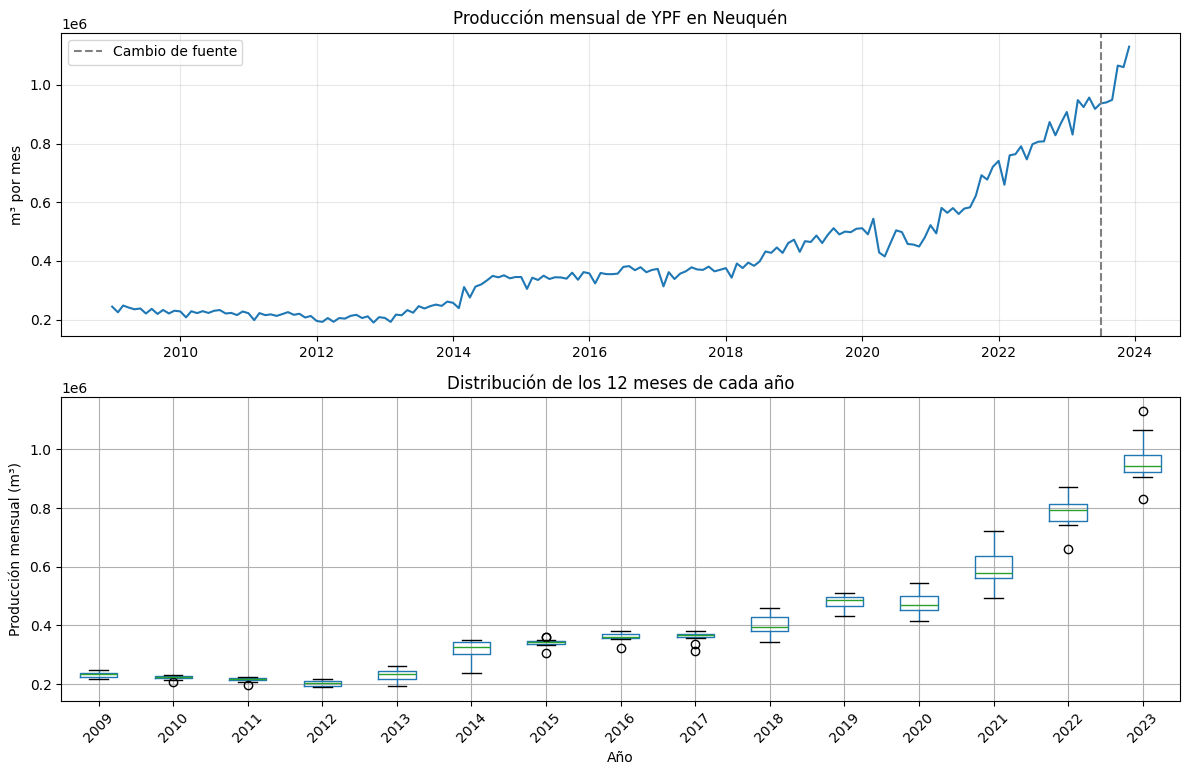

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

eda = serie.copy()
eda["anio"] = eda["fecha"].dt.year

meses_esperados = pd.date_range("2009-01-01", "2023-12-01", freq="MS")

print("Meses sin registro:", len(meses_esperados.difference(eda["fecha"])))
print("Fechas duplicadas:", eda["fecha"].duplicated().sum())
print("Producción faltante:", eda["produccion_m3"].isna().sum())
print("Producción negativa:", (eda["produccion_m3"] < 0).sum())

print("\nDistribución de la producción mensual (m³):")
display(eda["produccion_m3"].describe().round(2))

print("\nMeses y mediana por año:")
display(
    eda.groupby("anio").agg(
        meses=("fecha", "size"),
        mediana_mensual_m3=("produccion_m3", "median"),
    ).round(2)
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(eda["fecha"], eda["produccion_m3"])
ax1.axvline(pd.Timestamp("2023-07-01"), color="gray", linestyle="--",
            label="Cambio de fuente")
ax1.set_title("Producción mensual de YPF en Neuquén")
ax1.set_ylabel("m³ por mes")
ax1.legend()
ax1.grid(alpha=0.3)

eda.boxplot(column="produccion_m3", by="anio", ax=ax2, rot=45)
ax2.set_title("Distribución de los 12 meses de cada año")
ax2.set_xlabel("Año")
ax2.set_ylabel("Producción mensual (m³)")
fig.suptitle("")
plt.tight_layout()
plt.show()

Ajustamos la recta histórica para el Modelo de Entrenamiento Periodo 2009 - 2023


In [6]:
from sklearn.linear_model import LinearRegression

serie["mes_indice"] = range(len(serie))

X = serie[["mes_indice"]]
y = serie["produccion_m3"]

modelo = LinearRegression().fit(X, y)
serie["ajuste_m3"] = modelo.predict(X)

print(f"Pendiente: {modelo.coef_[0]:,.0f} m³ por mes")
print(f"Intercepto: {modelo.intercept_:,.0f} m³")
print(f"R² histórico: {modelo.score(X, y):.3f}")

display(
    serie[["fecha", "produccion_m3", "ajuste_m3"]]
    .tail(6)
    .round(2)
)

Pendiente: 3,713 m³ por mes
Intercepto: 80,817 m³
R² histórico: 0.786


,fecha,produccion_m3,ajuste_m3
174,2023-07-01,936667.41,726914.03
175,2023-08-01,940422.76,730627.23
176,2023-09-01,949228.98,734340.44
177,2023-10-01,1066015.44,738053.64
178,2023-11-01,1060804.34,741766.84
179,2023-12-01,1130562.63,745480.04


Preparamos los meses de prueba para el Modelo Perido 2024 - 2025

In [7]:
archivos_prueba = {
    2024: "produccin-de-pozo.csv",
    2025: "produccin-de-pozos-de-gas-y-petrle.csv",
}

partes = []

for anio, nombre in archivos_prueba.items():
    datos = pd.read_csv(
        carpeta / nombre,
        usecols=["anio", "mes", "idempresa", "provincia", "prod_pet"],
    )

    datos = datos.loc[
        (datos["anio"] == anio)
        & (datos["idempresa"] == "YPF")
        & (datos["provincia"] == "Neuquén")
    ]

    mensual = (
        datos.groupby(["anio", "mes"], as_index=False)["prod_pet"]
        .sum()
    )
    partes.append(mensual)

prueba = (
    pd.concat(partes, ignore_index=True)
    .rename(columns={"prod_pet": "produccion_real_m3"})
    .sort_values(["anio", "mes"])
    .reset_index(drop=True)
)

prueba["fecha"] = pd.to_datetime(
    dict(year=prueba["anio"], month=prueba["mes"], day=1)
)

if prueba.groupby("anio").size().to_dict() != {2024: 12, 2025: 12}:
    raise ValueError("Faltan meses en 2024 o 2025.")

print("Meses de prueba:", len(prueba))
display(
    prueba.groupby("anio").agg(
        meses=("mes", "size"),
        produccion_anual_m3=("produccion_real_m3", "sum"),
    ).round(2)
)
display(prueba.head(3), prueba.tail(3))

Meses de prueba: 24


,meses,produccion_anual_m3
anio,,
2024,12,13639618.57
2025,12,16579025.64


,anio,mes,produccion_real_m3,fecha
0,2024,1,1103256.21,2024-01-01
1,2024,2,1034898.00,2024-02-01
2,2024,3,1110575.00,2024-03-01


,anio,mes,produccion_real_m3,fecha
21,2025,10,1556428.33,2025-10-01
22,2025,11,1552688.35,2025-11-01
23,2025,12,1674923.97,2025-12-01


Medimos el Error

In [8]:
prueba["mes_indice"] = (
    (prueba["fecha"].dt.year - 2009) * 12
    + prueba["fecha"].dt.month - 1
)

prueba["pred_lineal_m3"] = modelo.predict(
    prueba[["mes_indice"]]
)

ultimo_2023 = serie.loc[
    serie["fecha"] == "2023-12-01", "produccion_m3"
].iloc[0]
prueba["referencia_m3"] = ultimo_2023

prueba["error_lineal_m3"] = (
    prueba["pred_lineal_m3"] - prueba["produccion_real_m3"]
)
prueba["abs_lineal_m3"] = prueba["error_lineal_m3"].abs()
prueba["abs_referencia_m3"] = (
    prueba["referencia_m3"] - prueba["produccion_real_m3"]
).abs()

resultados = prueba.groupby("anio").agg(
    real_anual_m3=("produccion_real_m3", "sum"),
    pred_lineal_anual_m3=("pred_lineal_m3", "sum"),
    MAE_lineal_m3=("abs_lineal_m3", "mean"),
    MAE_referencia_m3=("abs_referencia_m3", "mean"),
    suma_abs_lineal=("abs_lineal_m3", "sum"),
    suma_abs_referencia=("abs_referencia_m3", "sum"),
)

resultados["WAPE_lineal_pct"] = (
    100 * resultados["suma_abs_lineal"] / resultados["real_anual_m3"]
)
resultados["WAPE_referencia_pct"] = (
    100 * resultados["suma_abs_referencia"] / resultados["real_anual_m3"]
)
resultados["sesgo_lineal_pct"] = (
    100
    * (resultados["pred_lineal_anual_m3"] - resultados["real_anual_m3"])
    / resultados["real_anual_m3"]
)

print(f"Referencia fija: {ultimo_2023:,.2f} m³ por mes")
display(
    resultados[
        [
            "real_anual_m3",
            "pred_lineal_anual_m3",
            "MAE_lineal_m3",
            "MAE_referencia_m3",
            "WAPE_lineal_pct",
            "WAPE_referencia_pct",
            "sesgo_lineal_pct",
        ]
    ].round(2)
)

Referencia fija: 1,130,562.63 m³ por mes


,real_anual_m3,pred_lineal_anual_m3,MAE_lineal_m3,MAE_referencia_m3,WAPE_lineal_pct,WAPE_referencia_pct,sesgo_lineal_pct
anio,,,,,,,
2024,13639618.57,9235390.31,367019.02,66435.61,32.29,5.84,-32.29
2025,16579025.64,9770091.45,567411.18,251022.84,41.07,18.17,-41.07


Mostramos el resultado en un gráfico

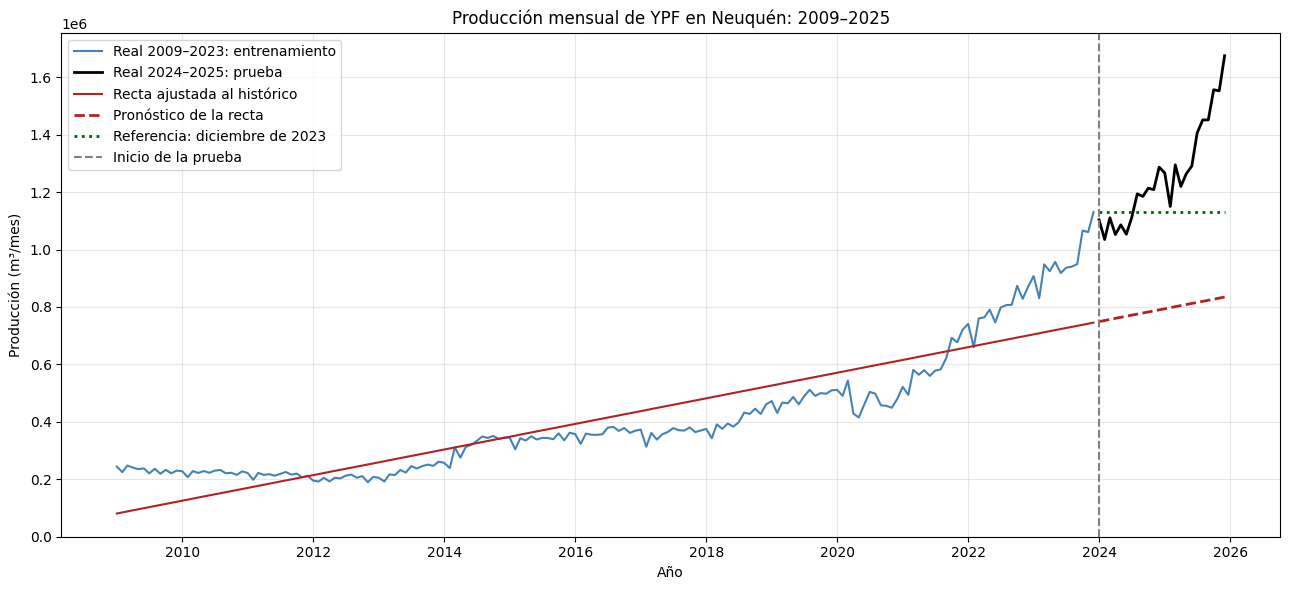

Gráfico completo guardado: /content/drive/MyDrive/C26240 | Machine_Learning | Talento_Techt/Proyecto YPF_ML/Datos/Datos_Procesados/ypf_neuquen_serie_completa_2009_2025.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(13, 6))

# Producción observada
ax.plot(
    serie["fecha"],
    serie["produccion_m3"],
    color="steelblue",
    label="Real 2009–2023: entrenamiento",
)
ax.plot(
    prueba["fecha"],
    prueba["produccion_real_m3"],
    color="black",
    linewidth=2,
    label="Real 2024–2025: prueba",
)

# La misma recta antes y después del corte temporal
ax.plot(
    serie["fecha"],
    modelo.predict(serie[["mes_indice"]]),
    color="firebrick",
    label="Recta ajustada al histórico",
)
ax.plot(
    prueba["fecha"],
    prueba["pred_lineal_m3"],
    color="firebrick",
    linestyle="--",
    linewidth=2,
    label="Pronóstico de la recta",
)

# Referencia usada solo en la prueba
ax.plot(
    prueba["fecha"],
    prueba["referencia_m3"],
    color="darkgreen",
    linestyle=":",
    linewidth=2,
    label="Referencia: diciembre de 2023",
)

ax.axvline(
    pd.Timestamp("2024-01-01"),
    color="gray",
    linestyle="--",
    label="Inicio de la prueba",
)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Producción mensual de YPF en Neuquén: 2009–2025")
ax.set_xlabel("Año")
ax.set_ylabel("Producción (m³/mes)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

salida = (
    carpeta.parent
    / "Datos_Procesados"
    / "ypf_neuquen_serie_completa_2009_2025.png"
)
fig.savefig(salida, dpi=180, bbox_inches="tight")
plt.show()

print("Gráfico completo guardado:", salida)

En el Grafico la separación entre la línea real y la recta es la desviación del pronóstico que acabamos de medir. El gráfico y la tabla permiten contar una historia técnica sencilla: ajustar bien el pasado no basta; hay que probar el modelo con meses posteriores y compararlo con una referencia.

La conclusión adicional más útil es que la recta no captó el ritmo de crecimiento reciente:
Cambio de 2024 a 2025	Producción real	Pronóstico lineal
Aumento anual	2,94 millones de m³ (21,6 %)	0,53 millones de m³ (5,8 %)

Una regresión lineal entrenada con 2009–2023 describió parte de la tendencia histórica, pero subestimó la producción de 2024 y 2025. Una referencia basada en el último mes observado obtuvo menor error en ambos años. El caso muestra por qué los pronósticos deben evaluarse con períodos futuros y compararse con métodos simples

Los datos de esta regresión muestran qué ocurrió con el volumen total, pero no identifican por sí solos la causa del crecimiento. Para investigar causas necesitaríamos incorporar, por ejemplo, pozos activos, altas de pozos y composición de la producción